<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/4_1_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson 4 – Distributions, Missing Values, and Outliers 1

In this lesson:

- We focus on **examining data distributions and outliers**, and on understanding what the statistical measures behind the data mean in practice.  
- We introduce the concept of **quartiles (Q1, Q2, Q3)** and the visual summary of a distribution.

The topic of the first notebook:

- **Outliers** and the **IQR- and Z-score–based approaches** for identifying them.  
- We will examine how extreme observations influence the **mean**,  
- the **distribution and visualizations**,  
- and why handling outliers is an **interpretative decision**, not just a technical step.

The goal of this lesson is **not to “fix” the data**, but to understand **how much we can trust the data** before performing further analysis or modeling.


## Wine Dataset

The Wine dataset is a classic and frequently used dataset that describes wines based on various chemical measurements. Each row represents a wine sample, and the columns contain numerical features derived from laboratory measurements.

The data belong to three different wine types,which makes the dataset well suited for examining **distributions**, **relationships between variables**, and **correlations**.

The Wine dataset contains **178 wine samples**, each described by **13 chemical features** and one **target variable**.  
The goal is to identify the **type (class) of wine** based on its chemical composition.

### Chemical Features

- **alcohol** – alcohol content  
- **alcohol_noise** – alcohol content **with added noise**  
- **malic_acid** – amount of malic acid (one component of acidity)  
- **malic_acid_noise** – amount of malic acid **with added noise**  
- **ash** – ash content (amount of mineral substances)  
- **ash_noise** – ash content **with added noise**  
- **alcalinity_of_ash** – alkalinity of ash  
- **magnesium** – magnesium content  
- **magnesium_noise** – magnesium content **with added noise**  
- **total_phenols** – total amount of phenolic compounds  
- **flavanoids** – amount of flavonoids (flavor, antioxidants)  
- **nonflavanoid_phenols** – non-flavonoid phenols  
- **proanthocyanins** – proanthocyanins (color, astringency)  
- **color_intensity** – intensity of color  
- **hue** – color tone  
- **od280/od315_of_diluted_wines** – optical density ratio, related to aroma and phenols  
- **proline** – amount of the amino acid proline (often a strong varietal indicator)

### Target Variable

- **target** – wine type (category), typically **3 different classes**

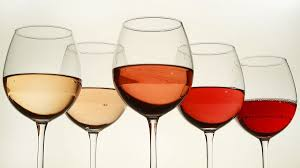

In [ ]:
# Loading the noisy WINE dataset
# The Wine dataset is a classic, fully numerical dataset
# that is often used for teaching statistical analysis and machine learning.

from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

# Load data
file_id = "1_A6F7SxeFGh6-u-MvSl39uFSGD6o1C2x"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_pickle(url)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_noise,malic_acid_noise,ash_noise,magnesium_noise
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,14.254836,1.696767,2.429074,127.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,13.193087,1.916008,2.125567,100.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,13.192384,2.391283,2.686136,101.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,14.446151,1.907142,2.458638,113.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,13.228292,2.536455,2.895967,NaN


Quick check

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

### Noisy Data

Since today’s lesson focuses on **outliers** and **missing values**,  
some attributes have been **artificially contaminated with noise**:

- `alcohol_noise`
- `malic_acid_noise`
- `ash_noise`
- `magnesium_noise`

In the following analysis, we will work with these **noisy columns**.

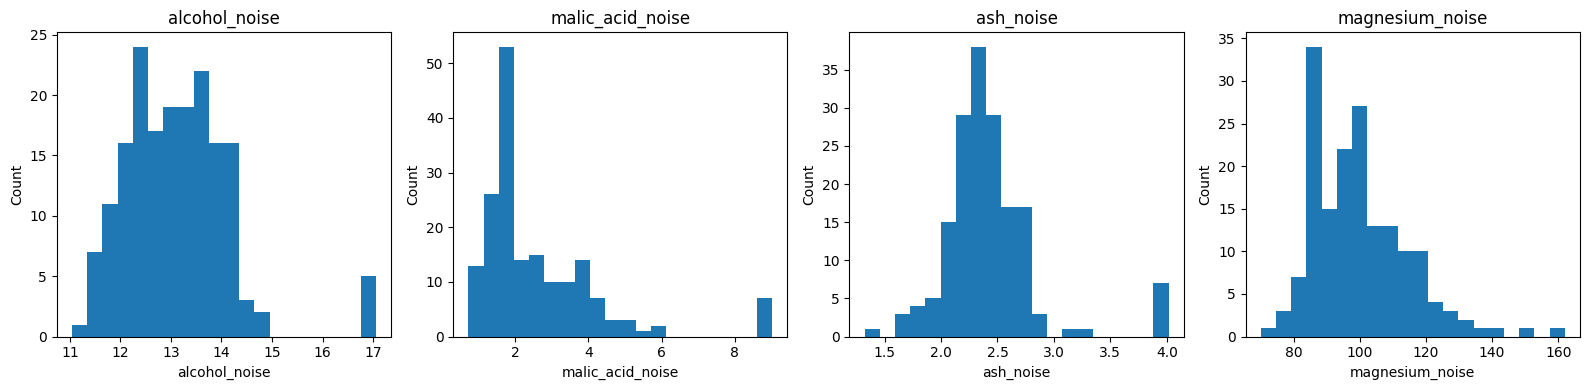

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns whose distributions we want to compare
noise_columns = ["alcohol_noise", "malic_acid_noise", "ash_noise", "magnesium_noise"]

# Create a figure with 1 row and multiple columns (subplots) so the histograms appear side by side
fig, axes = plt.subplots(1, len(noise_columns), figsize=(16, 4))

for ax, col in zip(axes, noise_columns):
    # Draw a histogram on the given axis (ax)
    df[col].plot(kind="hist", ax=ax, bins=20)

    # Set axis labels and title
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()  # adjust layout so labels do not overlap
plt.show()          # display the figure

### Visualizing Outliers with a Scatter Plot

Let’s take a look at the data *purely visually*.  
In the figure below, the values of a single numerical column are plotted as points along a “strip”.


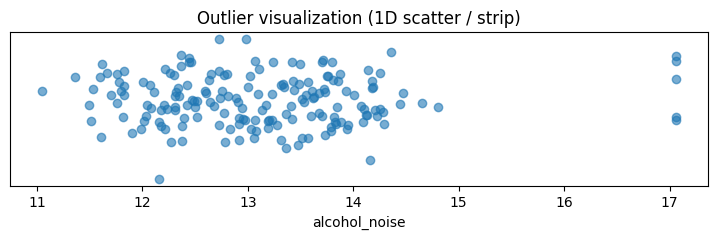

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select the numerical column to visualize and remove missing values (NaN)
# This ensures that the scatter plot works only with real numeric values.
x = df["alcohol_noise"].dropna()

# On the y-axis we do not plot real data, we only add a very small random "noise"
# so that the points do not completely overlap (this is called jitter).
y = np.random.normal(loc=0, scale=0.02, size=len(x))

# Set the size of the displayed plot
plt.figure(figsize=(9, 2))

# Create a "strip-like" scatter plot:
# - x axis: values of the variable
# - y axis: only jitter, no actual meaning
# The transparency of the points (alpha) helps denser regions become more visible.
plt.scatter(x, y, alpha=0.6)

# Hide the y-axis because it only has a technical role (jitter), not informational
plt.yticks([])

# Labels: what we see and which variable we are examining
plt.xlabel("alcohol_noise")
plt.title("Outlier visualization (1D scatter / strip)")

plt.show()

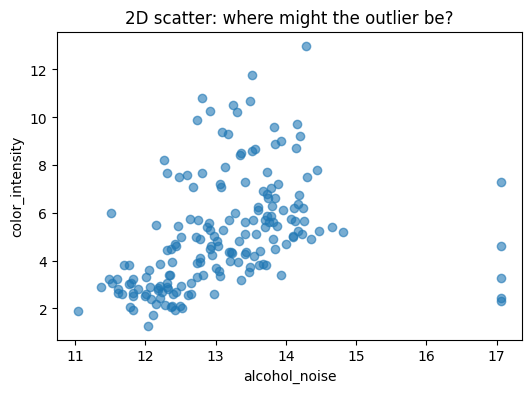

In [ ]:
# Set the size of the displayed plot
plt.figure(figsize=(6, 4))

# 2D scatter plot:
# - x axis: alcohol_noise (noisy version of alcohol values)
# - y axis: color_intensity
# The transparency of the points (alpha) helps denser regions become more visible.
plt.scatter(df["alcohol_noise"], df["color_intensity"], alpha=0.6)

# Axis labels
plt.xlabel("alcohol_noise")
plt.ylabel("color_intensity")

# Title
plt.title("2D scatter: where might the outlier be?")

plt.show()

### Q1, Q2, Q3 – Understanding the Distribution

A dataset can rarely be well described by a single number (such as the mean).  
To better understand the distribution, we divide the data into parts and examine where the values are located.

**Quartiles** divide the data into four equal parts:

- **Q1 (lower quartile):** the upper boundary of the lowest 25%  
- **Q2 (median):** the middle value of the data  
- **Q3 (upper quartile):** the lower boundary of the highest 25%

The **range between Q1 and Q3 (IQR – interquartile range)**  
describes the middle 50% of the distribution and is less sensitive to outliers than the mean.

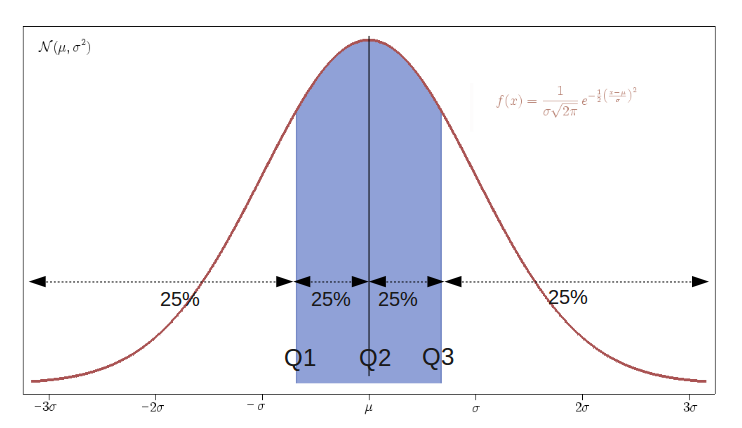


In [ ]:
# Calculate quartiles for one variable
col = "alcohol_noise"

q1 = df[col].quantile(0.25)
q2 = df[col].quantile(0.50)
q3 = df[col].quantile(0.75)

q1, q2, q3


(np.float64(12.3637384917973),
 np.float64(13.060875163977617),
 np.float64(13.728780072325549))

In [ ]:
df[col].describe()

,alcohol_noise
count,178.000000
mean,13.118139
std,1.049638
min,11.045077
25%,12.363738
50%,13.060875
75%,13.728780
max,17.059267


**What do we see?**

The quartiles of the `alcohol` variable show that the middle 50% of the data lie between **Q1 = 12.36** and **Q3 = 13.72**.  
The median (Q2 ≈ 13.06) is close to the mean, which suggests a relatively symmetric distribution.  
However, the maximum value lies much farther away, which may indicate the presence of outliers.


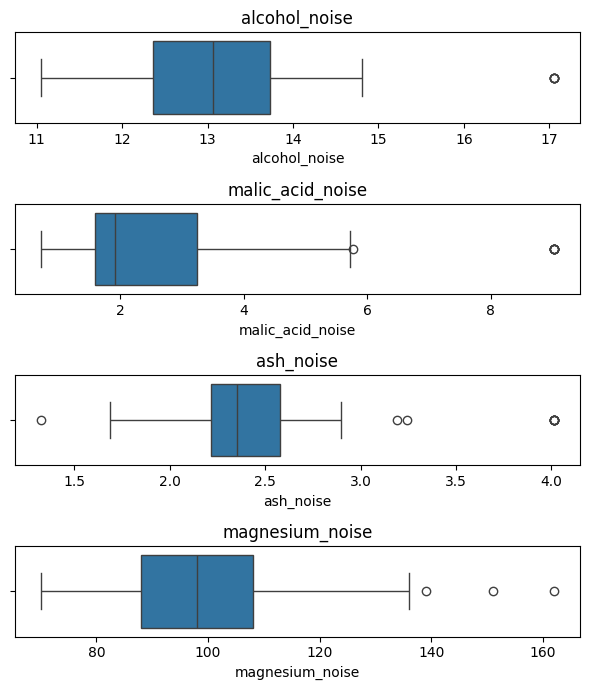

In [ ]:
# Select the last few numerical columns
cols = df.select_dtypes(include="number").columns[-4:]

# Create multiple plots arranged in a single column:
# - len(cols) rows, 1 column → each variable gets its own boxplot
# - figsize: size of the entire figure
# - sharex=False: each boxplot can have its own x-axis scale (due to different units)
fig, axes = plt.subplots(len(cols), 1, figsize=(6, 7), sharex=False)

# Iterate through the axes and column names in pairs
for ax, col in zip(axes, cols):
    # Boxplot: quickly shows the main characteristics of the distribution
    # (median, quartiles, and potential outliers)
    sns.boxplot(x=df[col], ax=ax)

    # The title of each subplot will be the column name
    ax.set_title(col)

plt.tight_layout()  # Automatically adjust subplots so titles/axes do not overlap
plt.show()          # Display the figure

**What do we see?**

- Each boxplot shows the distribution of one variable.  
- The box represents the middle 50% of the data (Q1–Q3), and the line indicates the median.  
- The individual points suggest possible outliers.

It is clearly visible that the distributions of the variables differ:

- In some cases the data are relatively symmetric, while in others there is a long “tail”.  
- In some variables several outliers appear.

### Outliers

Outliers are observations that differ significantly from the majority of the data.  
They can distort the mean, the distribution, and visualizations,  
so it is important to identify and handle them consciously.


In [ ]:
# Variable under investigation
col = "alcohol_noise"

df[col].describe()


,alcohol_noise
count,178.000000
mean,13.118139
std,1.049638
min,11.045077
25%,12.363738
50%,13.060875
75%,13.728780
max,17.059267


**Brief explanation**

The distribution of the `alcohol` variable is well bounded between the quartiles,  
however, the maximum value lies much farther from the upper quartile.  
This suggests that possible outliers at the upper end of the data  
may influence the distribution and the summary statistics.


**What is the IQR method?**

The IQR (Interquartile Range) method is used to identify outliers and is based on the middle 50% of the data.

Values are considered outliers if they fall outside the interval**Q1 − 1.5 × IQR** or **Q3 + 1.5 × IQR**.

The advantage of the IQR method is that it is less sensitive to extreme observations than methods based on the mean and standard deviation.

In [ ]:
# Calculate quartiles and IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

# Lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(10.316176121004926), np.float64(15.776342443117922))

In [ ]:
# Create a copy so the original data remains unchanged
df_iqr = df.copy()

# Replace outliers with NaN
df_iqr.loc[
            (df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound),
            col
        ] = np.nan

In [ ]:
df_iqr[col].describe()


,alcohol_noise
count,173.000000
mean,13.004233
std,0.818042
min,11.045077
25%,12.344309
50%,13.024086
75%,13.699915
max,14.806526


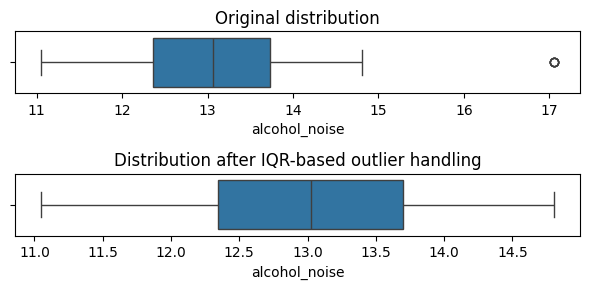

In [ ]:
# Create two subplots one below the other:
# - 2 rows, 1 column → original distribution on top, cleaned distribution below
# - figsize: size of the entire figure
fig, axes = plt.subplots(2, 1, figsize=(6, 3))

# Boxplot for the original data
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title("Original distribution")

# Boxplot for the data after outlier handling (filtered using the IQR method)
# df_iqr contains the same columns, but the outliers have been replaced with NaN.
sns.boxplot(x=df_iqr[col], ax=axes[1])
axes[1].set_title("Distribution after IQR-based outlier handling")

plt.tight_layout()  # Adjust subplot layout so titles do not overlap
plt.show()


### Important note about boxplot “whiskers”

In a boxplot, we first compute the theoretical boundaries:

- lower bound: `Q1 - 1.5 × IQR`
- upper bound: `Q3 + 1.5 × IQR`

However, the whiskers **do not necessarily extend exactly to these values**.

The actual whiskers are defined as follows:

- the **lower whisker** extends to the **smallest observed data point** that is still within the boundary,
- the **upper whisker** extends to the **largest observed data point** that is still within the boundary.

In other words, the `1.5 × IQR` rule only defines a **threshold**,  
but the whisker ends at a **real data point** within that threshold.

Because of this:

- whiskers may have different lengths,
- and their endpoints do not necessarily coincide with the theoretical boundary.

Points that fall outside these limits are displayed separately in the boxplot  
and are considered **potential outliers**.

### Visual Effect of IQR Filtering (df vs df_iqr)

In the previous step, the outliers (based on the IQR rule) were **not deleted**, but **replaced with NaN** in the `df_iqr` DataFrame.

Now we will look at this effect using a **2D scatter plot**:



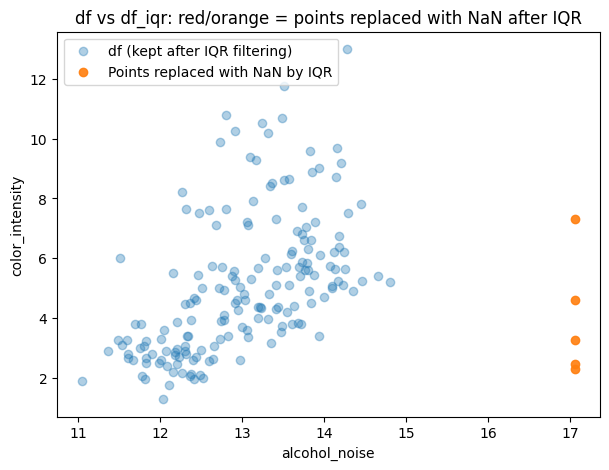

In [ ]:
import matplotlib.pyplot as plt

# Which two columns do you want to visualize in the scatter plot?
x_col = "alcohol_noise"
y_col = "color_intensity"

# A point is considered "dropped" if any of its values became NaN after IQR filtering
dropped_mask = df_iqr[x_col].isna()

# The "kept" points are those that are not NaN in df_iqr
kept_mask = ~dropped_mask

plt.figure(figsize=(7, 5))

# Original df: points that remained after IQR filtering (blue)
plt.scatter(
    df.loc[kept_mask, x_col],
    df.loc[kept_mask, y_col],
    alpha=0.35,
    label="df (kept after IQR filtering)"
)

# Original df: points that were removed (orange) – these became NaN in df_iqr
plt.scatter(
    df.loc[dropped_mask, x_col],
    df.loc[dropped_mask, y_col],
    alpha=0.9,
    label="Points replaced with NaN by IQR"
)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("df vs df_iqr: red/orange = points replaced with NaN after IQR")
plt.legend()
plt.show()

**Key idea**

The IQR-based method treats observations outside the typical value range as outliers.

Handling them can reduce distortion in the distribution, but it may also lead to loss of information.  
Therefore, it is always an **interpretative decision**, not an automatic step.


### Should we always replace outliers with NaN?

In the previous example, the outliers detected by the IQR rule were replaced with `np.nan`.  
This is **not mandatory and not a “default rule.”**

Handling outliers is an **analyst’s decision**, which always depends on the meaning of the data and the context.

Possible strategies include:

- **Keeping them** (if the outlier is real but rare)
- **Flagging them** (adding a separate “outlier” indicator column)
- **Winsorization / capping** (limiting extremely large or small values to a threshold)
- **Setting to NaN + imputation** (mean / median / ffill / bfill – depending on context)
- **Dropping the row** (if there are few and they are clearly erroneous)

**Example:**

- In continuous physical measurements (e.g., a temperature sensor), an outlier is often a measurement error → replacing it with `NaN` and imputing may be justified.  
- In healthcare data (e.g., heart rate), an outlier may represent a rare but real event → in this case it is better to be cautious, perhaps flag it and analyze it separately.

**Key idea:** the IQR rule only flags **“suspicious values”** – the final decision must be made by the analyst.

### Two Common Alternatives for Handling Outliers

**Z-score (mean + standard deviation)**  
- A value is considered an outlier if, for example, `|z| > 3`.  
- Works well when the distribution is approximately **normal** and there are not too many extreme values. (We will learn about different distributions in the next lesson.)  
- Disadvantage: outliers can **inflate** the mean and the standard deviation.  
- The Z-score (standardized value) tells us how many standard deviations a data point is from the mean.

**Capping / winsorizing (truncation at percentiles)**  
- Example: values below the 1st percentile and above the 99th percentile are **capped at those thresholds**.  
- Useful when outliers carry information, but we do not want them to overly influence a model.  
- Disadvantage: it **hides the extremeness** rather than explicitly marking it.



In [ ]:
# Z-score–based outlier detection for the noisy columns
# Idea: standardize the values (z-score) and treat them as outliers if |z| is large (e.g., > 3).

noise_columns = ["alcohol_noise", "malic_acid_noise", "ash_noise"]
z_thresh = 3  # typical threshold: values farther than 3 standard deviations are considered outliers

df_z = df.copy()  # we will write the NaNs here

for col in noise_columns:
    # Z-score: how many standard deviations the value is from the mean
    z = (df[col] - df[col].mean()) / df[col].std(ddof=0)  # ddof=0: divide by N; ddof=1: sample std (N-1)

    # Boolean mask for one column (True where outlier)
    is_outlier = z.abs() > z_thresh

    # Replace outliers with NaN using loc
    df_z.loc[is_outlier, col] = np.nan

    # Quick feedback: how many outliers were found
    print(f"{col}: Z-score outliers (|z|>{z_thresh}) = {is_outlier.sum()}")

# Check: how many NaNs were created per column
df_z[noise_columns].isna().sum()

alcohol_noise: Z-score outliers (|z|>3) = 5
malic_acid_noise: Z-score outliers (|z|>3) = 7
ash_noise: Z-score outliers (|z|>3) = 7


,0
alcohol_noise,5
malic_acid_noise,7
ash_noise,15


### Rare Categories as “Categorical Outliers”

In numerical variables, an outlier is an **unusually large or small value**.  
For categorical variables there is no concept of magnitude, so “standing out” appears differently:

- **Rare category**: a label that occurs only a few times in the dataset.
- These can be problematic because they may lead to **unstable estimates** in analysis and modeling,
  and in One-Hot Encoding they can create **too many columns**.

Now we will look at a dataset where some categories appear frequently, while others are rare.

In [ ]:
# Bank Marketing dataset (OpenML)
# Note: there are multiple "bank-marketing" datasets on OpenML.
# Here we use one of the typical OpenML versions.
# Load data

file_id = "1ssrXsYpNJSzfgn9-txa-Yp12ji3Lrsrr"  # note: two r's at the end
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv"
df_bank = pd.read_csv(url)

df_bank.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,1
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,1
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,1
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,1
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,1


In [ ]:
# Select a categorical column with small-to-medium cardinality
col = "job"  # often good examples: job, education, marital, contact

# Frequency of categories (groupby + size)
freq = (
    df_bank.dropna(subset=[col])
    .groupby(col)
    .size()
    .sort_values(ascending=False)
)

display(freq.head(10))

# Identify "rare" categories (e.g., <= 50 occurrences)
rare_threshold = 15
rare = freq[freq <= rare_threshold].sort_values()

print(f"Total number of categories: {freq.shape[0]}")
print(f"Number of rare categories (<= {rare_threshold} occurrences): {rare.shape[0]}")
display(rare.head(15))


,0
job,
management,951
blue-collar,946
technician,765
admin.,478
services,405
retired,230
self-employed,183
entrepreneur,168
unemployed,128


Total number of categories: 17
Number of rare categories (<= 15 occurrences): 5


,0
job,
bbb,3
rgrg,6
BLA-BLA,8
rgp,12
12,12


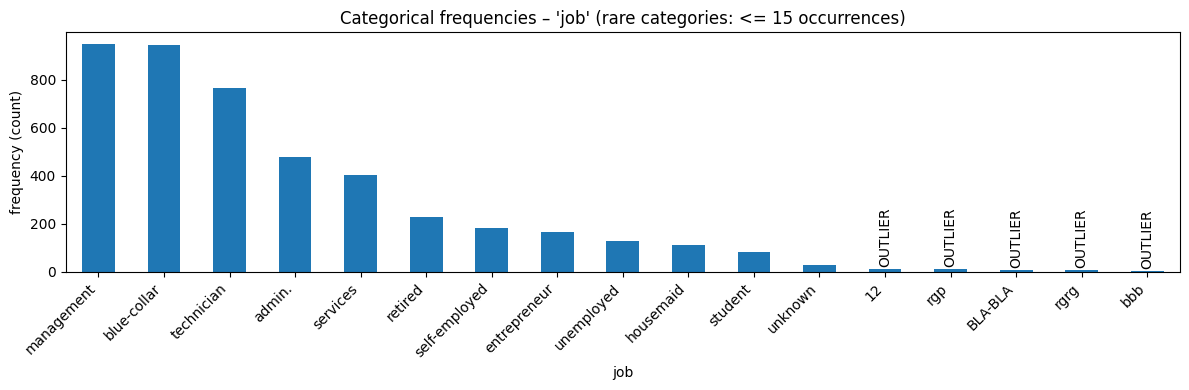

In [ ]:
import matplotlib.pyplot as plt

col = "job"              # which categorical column are we analyzing?
rare_threshold = 15      # <= this number of occurrences = rare (outlier-like)

# Frequency
freq = df_bank.groupby(col).size().sort_values(ascending=False)

# List of rare categories (e.g., bbb, rgrg, BLA-BLA, ...)
rare_cats = freq[freq <= rare_threshold].index.tolist()

# Barplot: all categories + label rare ones as "OUTLIER"
plt.figure(figsize=(12, 4))
ax = freq.plot(kind="bar")

# Highlight rare categories with labels (not just a single BLA-BLA)
for cat in rare_cats:
    pos = list(freq.index).index(cat)
    count = int(freq.loc[cat])
    ax.text(pos, count + max(freq) * 0.01, "OUTLIER", ha="center", va="bottom", rotation=90)

plt.title(f"Categorical frequencies – '{col}' (rare categories: <= {rare_threshold} occurrences)")
plt.xlabel(col)
plt.ylabel("frequency (count)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Merging Rare Categories (Rare / Other)

In categorical variables, “standing out” often appears not in the *content* but in the *frequency*:
there may be several categories that occur only a few times in the dataset.

In such cases, a practical (and often effective) solution is **merging rare categories**:

- Define a threshold (e.g., `< 20` occurrences).
- Categories below the threshold are replaced with a common label such as `"RARE"` or `"OTHER"`.
- Frequent categories remain unchanged.

This reduces the number of categories, makes statistical estimates more stable,
and prevents One-Hot Encoding from creating many columns for extremely rare categories.

In [ ]:
# Merge rare categories into a common "RARE" label

col = "job"         # which categorical column we are working with
min_count = 20      # threshold: fewer occurrences than this -> "RARE"
rare_label = "RARE" # name of the merged label

# Calculate frequencies
freq = df_bank[col].value_counts(dropna=False)

# List of rare categories
rare_cats = freq[freq < min_count].index


In [ ]:
# Create a new column (recommended so the original remains unchanged)
new_col = f"{col}_grouped"
df_bank[new_col] = df_bank[col].where(~df_bank[col].isin(rare_cats), other=rare_label)

# Check: how many categories existed / remain, and what happened to the rare ones
print(f"Number of original categories: {df_bank[col].nunique(dropna=False)}")
print(f"Number of merged categories: {df_bank[new_col].nunique(dropna=False)}\n")

print("Top categories (after merging):")
display(df_bank[new_col].value_counts().head(15))

print("\nHow many items were placed into the 'RARE' group?")
display((df_bank[new_col] == rare_label).sum())

Number of original categories: 17
Number of merged categories: 13

Top categories (after merging):


,count
job_grouped,
management,951
blue-collar,946
technician,765
admin.,478
services,405
retired,230
self-employed,183
entrepreneur,168
unemployed,128



How many items were placed into the 'RARE' group?


np.int64(41)

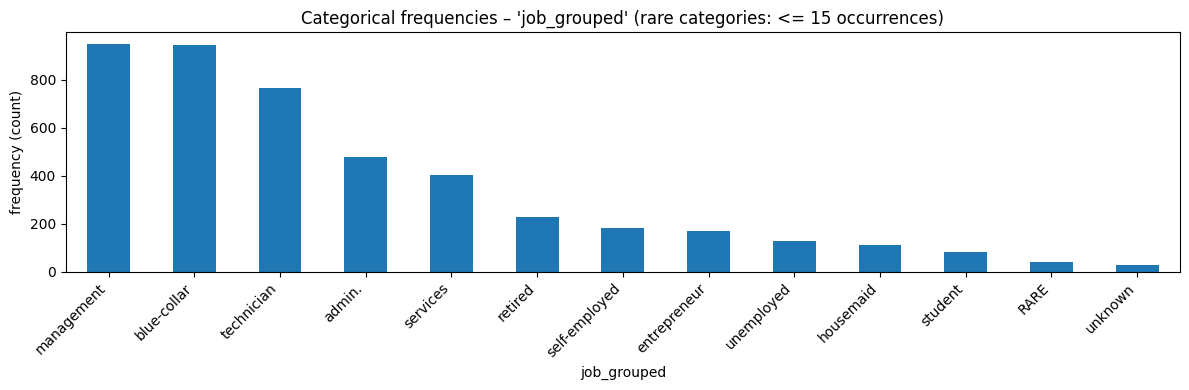

In [ ]:
col = "job_grouped"      # which categorical column are we analyzing?
rare_threshold = 15      # <= this number of occurrences = rare (outlier-like)

# Frequency
freq = df_bank.groupby(col).size().sort_values(ascending=False)

# List of rare categories (e.g., bbb, rgrg, BLA-BLA, ...)
rare_cats = freq[freq <= rare_threshold].index.tolist()

# Barplot: all categories + label rare ones as "OUTLIER"
plt.figure(figsize=(12, 4))
ax = freq.plot(kind="bar")

# Highlight rare categories with labels (not just a single BLA-BLA)
for cat in rare_cats:
    pos = list(freq.index).index(cat)
    count = int(freq.loc[cat])
    ax.text(pos, count + max(freq) * 0.01, "OUTLIER", ha="center", va="bottom", rotation=90)

plt.title(f"Categorical frequencies – '{col}' (rare categories: <= {rare_threshold} occurrences)")
plt.xlabel(col)
plt.ylabel("frequency (count)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Exercises


## Bank Marketing Dataset

The Bank Marketing dataset is a classic and frequently used dataset  
that describes the outcomes of a bank’s telephone marketing campaigns.  
Each row represents a customer contact,  
and the columns contain customer characteristics and campaign-related variables.

The dataset is well suited for examining the frequencies of categorical variables,  
demonstrating rare categories (categorical “outliers”),  
and analyzing the distributions and outliers of numerical variables.


The Bank Marketing dataset contains customer-campaign observations,  
described by several **categorical** and **numerical features**, as well as a **target variable (`y`)**.  
The goal is to understand under which conditions a contact is **successful**  
(for example, whether the customer accepts the offer).

### Categorical Features

- **job** – occupation  
- **marital** – marital status  
- **education** – level of education  
- **default** – whether the customer has credit in default (yes/no)  
- **housing** – whether the customer has a housing loan (yes/no)  
- **loan** – whether the customer has a personal loan (yes/no)  
- **contact** – type of communication (e.g., telephone/mobile/unknown)  
- **month** – month of contact  
- **poutcome** – outcome of the previous campaign (e.g., success/failure/unknown)

### Numerical Features

- **age** – age  
- **balance** – account balance  
- **day** – day of the month when the contact was made  
- **duration** – duration of the call (in seconds)  
- **campaign** – number of contacts performed during this campaign  
- **pdays** – number of days since the previous contact (if any)  
- **previous** – number of previous contacts

### Target Variable

- **y** – outcome of the campaign (whether the contact was successful / whether the customer accepted the offer)

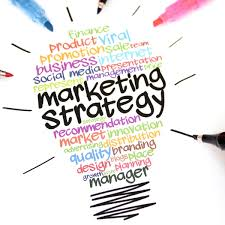

In [ ]:
# Load data
file_id = "1ssrXsYpNJSzfgn9-txa-Yp12ji3Lrsrr"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv"
df_bank = pd.read_csv(url)

df_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,1
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,1
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,1
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,1
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,1


In [ ]:
# Basic information
df_bank.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   int64 
dtypes: int64(8), object(9)
memory usage: 600.6+ KB


### Task 1 – Visual Identification of Outliers (Distribution + Boxplot)

Select **3 numerical variables** from the following list:  
`age`, `balance`, `duration`, `campaign`, `pdays`, `previous`.

1) Create a **histogram** for each variable.  
2) Create a **boxplot** for each variable.



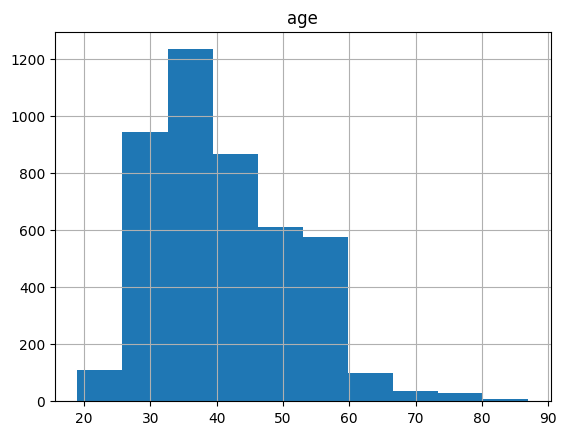

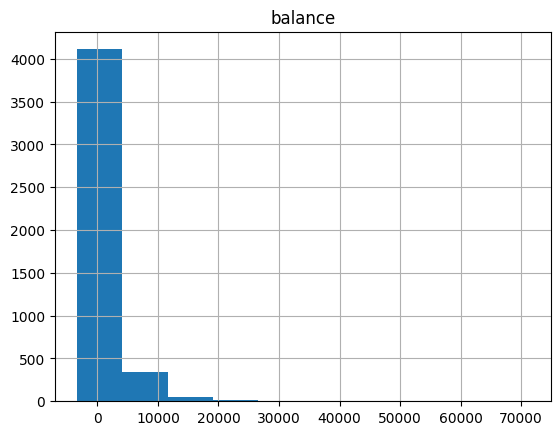

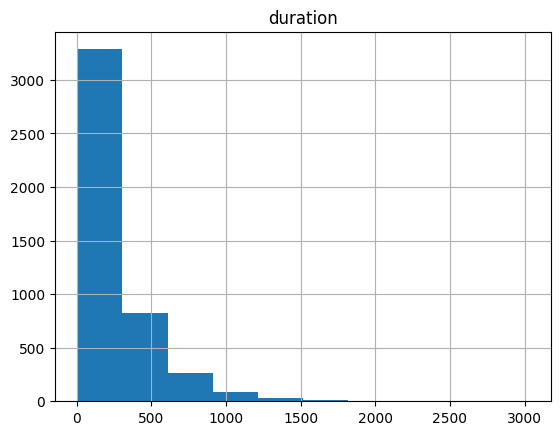

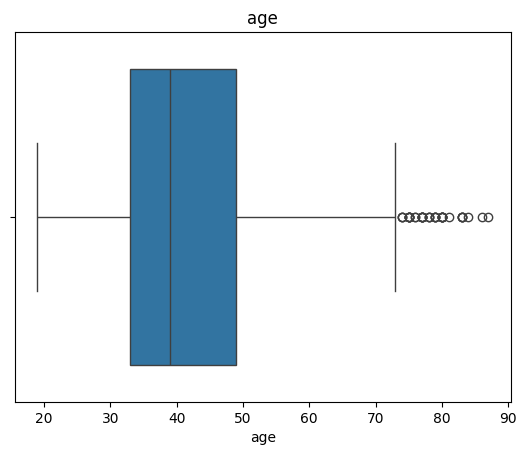

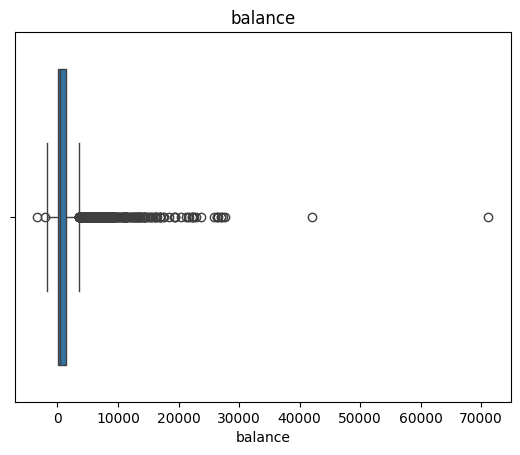

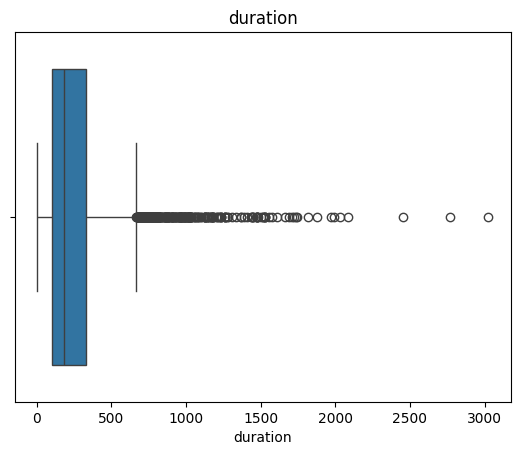

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_id = "1ssrXsYpNJSzfgn9-txa-Yp12ji3Lrsrr"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv"
df_bank = pd.read_csv(url)

cols = ["age","balance","duration"]

for c in cols:
    df_bank[c].hist()
    plt.title(c)
    plt.show()

for c in cols:
    sns.boxplot(x=df_bank[c])
    plt.title(c)
    plt.show()

### Task 2 – IQR-Based Outlier Detection and Replacing Values with NaN

Select the `balance` variable (if it contains too many zeros, you may also try `duration`).

1) Calculate the values of Q1, Q3, and the IQR.  
2) Determine the lower and upper thresholds:  
   - `lower = Q1 - 1.5 * IQR`
   - `upper = Q3 + 1.5 * IQR`
3) Create a copy called `df_iqr`, and replace values outside the thresholds with **NaN**.  
4) Count how many values were replaced with NaN.  
5) Plot the same variable **before and after IQR filtering** (for example, using a boxplot or histogram).


506


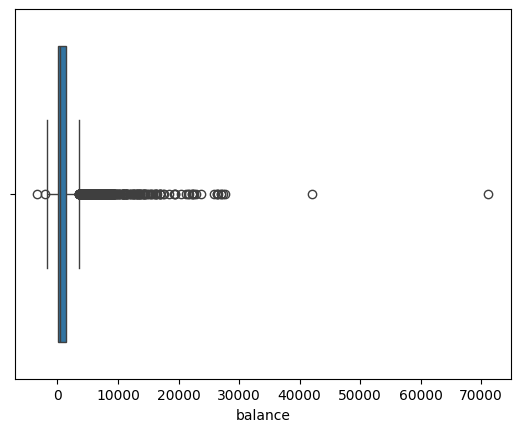

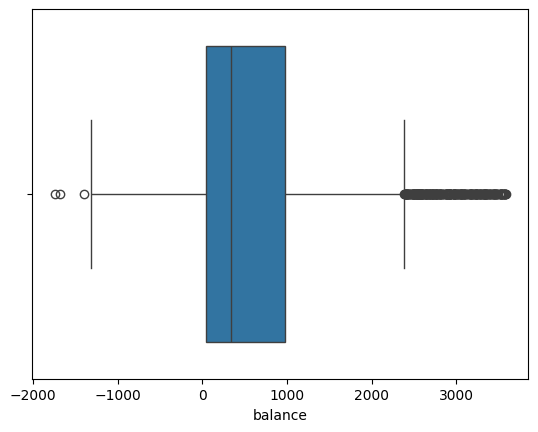

In [2]:
df_iqr = df_bank.copy()

Q1 = df_iqr["balance"].quantile(0.25)
Q3 = df_iqr["balance"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (df_iqr["balance"] < lower) | (df_iqr["balance"] > upper)
count_nan = mask.sum()

df_iqr.loc[mask, "balance"] = None

print(count_nan)

sns.boxplot(x=df_bank["balance"])
plt.show()

sns.boxplot(x=df_iqr["balance"])
plt.show()

### Task 3 – Z-score Based Outliers and Comparison with IQR

Choose a numerical variable: `duration` or `balance`.

1) Calculate the Z-score:  
   - `z = (x - mean) / std`

2) Mark a value as an outlier if `|z| > 3` (you can also try `2.5`).  

3) Count how many points are classified as outliers according to the Z-score.  

4) Compare the result with the IQR method:  
   - Do they identify the same points?  
   - Which method is **stricter** for this variable?


In [3]:
import numpy as np

x = df_bank["balance"]
z = (x - x.mean()) / x.std()

outliers_z = (abs(z) > 3)
print(outliers_z.sum())

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = (x < lower) | (x > upper)
print(outliers_iqr.sum())

88
506


### Task 4 – Highlighting Outliers in a Scatter Plot + Contextual Interpretation

Choose two numerical variables, for example: `age` and `balance`, or `duration` and `campaign`.

1) Create a **scatter plot** using the two variables.  
2) Highlight in **red** the points that are outliers in one of the variables  
   (you may choose either the **IQR** or **Z-score** method).


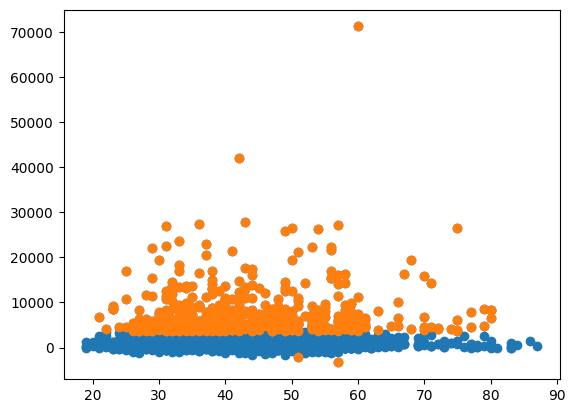

In [4]:
Q1 = df_bank["balance"].quantile(0.25)
Q3 = df_bank["balance"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (df_bank["balance"] < lower) | (df_bank["balance"] > upper)

plt.scatter(df_bank["age"], df_bank["balance"])
plt.scatter(df_bank.loc[outliers, "age"], df_bank.loc[outliers, "balance"])
plt.show()